# E-Commerce Sales Analysis

## 프로젝트 개요

온라인 소매 판매 데이터를 활용하여 매출, 고객, 상품 관점에서 EDA를 수행하였다.

## 1. 데이터 불러오기 (Data Loading)


본 프로젝트에서는 Online Retail 데이터를 SQLite 데이터베이스에 저장한 후, Pandas를 사용하여 데이터를 불러왔다.

분석에 사용된 데이터는 주문 정보, 상품 정보, 고객 정보, 국가 정보 등을 포함한다.

In [380]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

conn = sqlite3.connect("ecommerce.db")

df = pd.read_sql_query(
    "SELECT * FROM data",
    conn
)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850,United Kingdom


In [381]:
# 원본 데이터 (Raw Data)
df.shape

(541909, 8)

## 2. 데이터 정제 (Data Cleaning)

분석의 정확성을 높이기 위해 취소 주문, 재고 조정 데이터, 고객 ID가 없는 데이터를 제거하였다.

### 취소 주문 제거 (Remove Cancelled Orders)

취소 주문은 InvoiceNo가 'C'로 시작하는 특징을 가진다.

실제 판매 데이터만 분석하기 위해 해당 주문을 제거하였다.

In [384]:
cancel_mask = df["InvoiceNo"].str.startswith("C", na=False)

normal_df = df[~cancel_mask].copy()

normal_df.shape

(532621, 8)

### 재고 조정 데이터 제거(Remove Inventory Adjustment Records)

Quantity가 음수이고 Description이 비어있는 데이터는 실제 판매가 아닌 재고 조정(Inventory Adjustment) 기록으로 판단하였다.

In [386]:
clean_df = normal_df[
    ~(
        (normal_df["Quantity"] < 0)
        &
        (normal_df["Description"] == "")
    )
].copy()

clean_df.shape

(531759, 8)

### CustomerID 결측 제거 (Remove Missing CustomerID)

고객 분석을 수행하기 위해 CustomerID가 없는 데이터를 제거하였다.

CustomerID가 없는 경우 고객별 매출 및 구매 패턴 분석이 불가능하다.

In [388]:
clean_df = clean_df[
    clean_df["CustomerID"] != ""
].copy()

clean_df.shape

(397924, 8)

### 정제 결과 확인 (Data Cleaning Result)

- 원본 데이터: 541,909건
- 취소 주문 제거 후: 532,621건 (-9,288건)
- 재고 조정 데이터 제거 후: 531,759건 (-862건)
- CustomerID 결측 제거 후: 397,924건 (-133,835건)

최종적으로 397,924건의 판매 데이터가 분석에 사용되었다.

## 3. 특성 생성 (Feature Engineering)

분석에 필요한 추가 컬럼을 생성하였다.

- InvoiceDate를 datetime 형식으로 변환
- Year 컬럼 생성
- Month 컬럼 생성
- YearMonth 컬럼 생성
- Sales(매출) 컬럼 생성

### 날짜 데이터 변환 (Datetime Conversion)

InvoiceDate 컬럼은 문자열(Object) 형식으로 저장되어 있다.

날짜 기반 분석을 수행하기 위해 datetime 형식으로 변환하였다.

In [392]:
clean_df["InvoiceDate"] = pd.to_datetime(
    clean_df["InvoiceDate"]
)

clean_df["InvoiceDate"].head()

0   2010-12-01 08:26:00
1   2010-12-01 08:26:00
2   2010-12-01 08:26:00
3   2010-12-01 08:26:00
4   2010-12-01 08:26:00
Name: InvoiceDate, dtype: datetime64[ns]

### 연도 및 월 컬럼 생성 (Year and Month Features)

연도(Year)와 월(Month) 컬럼을 생성하여 연도별 및 월별 매출 분석이 가능하도록 하였다.

In [394]:
clean_df["Year"] = clean_df["InvoiceDate"].dt.year

clean_df["Month"] = clean_df["InvoiceDate"].dt.month

clean_df[
    ["InvoiceDate", "Year", "Month"]
].head()

,InvoiceDate,Year,Month
0,2010-12-01 08:26:00,2010,12
1,2010-12-01 08:26:00,2010,12
2,2010-12-01 08:26:00,2010,12
3,2010-12-01 08:26:00,2010,12
4,2010-12-01 08:26:00,2010,12


### 연-월 컬럼 생성 (Year-Month Feature)

월별 매출 추이를 분석하기 위해 InvoiceDate를 연-월(Year-Month) 단위로 변환하였다.

이를 통해 동일한 월에 발생한 주문을 하나의 그룹으로 묶어 집계할 수 있다.

In [396]:
clean_df["YearMonth"] = (
    clean_df["InvoiceDate"]
    .dt.to_period("M")
)

clean_df[
    ["InvoiceDate", "YearMonth"]
].head()

,InvoiceDate,YearMonth
0,2010-12-01 08:26:00,2010-12
1,2010-12-01 08:26:00,2010-12
2,2010-12-01 08:26:00,2010-12
3,2010-12-01 08:26:00,2010-12
4,2010-12-01 08:26:00,2010-12


### 매출 컬럼 생성 (Sales Feature)

Sales 컬럼은 Quantity(판매 수량)와 UnitPrice(상품 단가)를 곱하여 생성하였다.

이를 통해 이후 고객, 상품, 국가별 매출 분석을 수행할 수 있다.

In [398]:
clean_df["Sales"] = (
    clean_df["Quantity"]
    * clean_df["UnitPrice"]
)

clean_df[
    ["Quantity", "UnitPrice", "Sales"]
].head()

,Quantity,UnitPrice,Sales
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


### 특성 생성 결과 확인 (Feature Engineering Result)

날짜 관련 컬럼(Year, Month, YearMonth)과
매출 컬럼(Sales)을 생성하여 이후 분석에 활용하였다.

## 4. 월별 매출 분석 (Monthly Sales Analysis)

YearMonth 컬럼을 기준으로 월별 매출을 집계하였다.

이를 통해 시간에 따른 매출 변화를 확인하고, 계절성(Seasonality) 및 성장 추세(Trend)를 분석하고자 한다.

### 월별 매출 집계 (Monthly Sales Aggregation)

YearMonth 기준으로 Sales를 합산하여 각 월의 총 매출을 계산하였다.

In [402]:
yearmonth_sales = (
    clean_df
    .groupby("YearMonth")["Sales"]
    .sum()
)

yearmonth_sales

YearMonth
2010-12     572713.890
2011-01     569445.040
2011-02     447137.350
2011-03     595500.760
2011-04     469200.361
2011-05     678594.560
2011-06     661213.690
2011-07     600091.011
2011-08     645343.900
2011-09     952838.382
2011-10    1039318.790
2011-11    1161817.380
2011-12     518192.790
Freq: M, Name: Sales, dtype: float64

### 월별 매출 추이 시각화 (Monthly Sales Trend Visualization)

월별 매출 데이터를 시각화하여 시간에 따른 매출 변화 추이를 확인하였다.

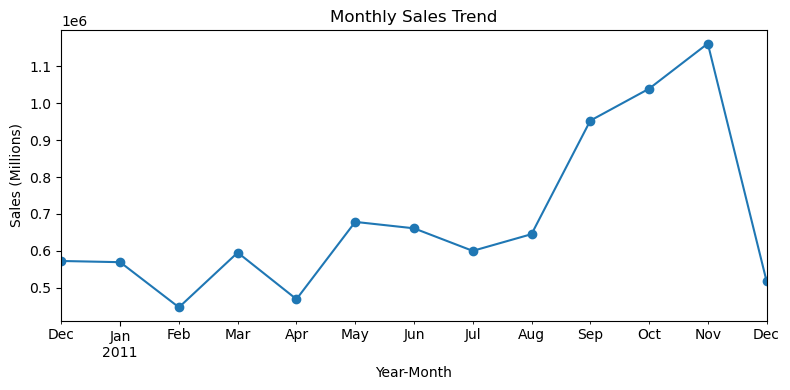

In [404]:
yearmonth_sales.plot(
    figsize=(8,4),
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Year-Month")
plt.ylabel("Sales (Millions)")

plt.tight_layout()
plt.show()

### 분석 결과 (Key Findings)

- 2011년 하반기로 갈수록 매출이 지속적으로 증가하는 추세를 보였다.
- 2011년 9월 이후 매출이 급격히 증가하였으며, 11월에 최고 매출을 기록하였다.
- 2011년 12월 매출 감소는 데이터 수집 기간이 월 전체를 포함하지 않았기 때문으로 판단된다.

## 5. 국가별 매출 분석 (Country Sales Analysis)

국가별 총 매출을 집계하여 매출이 높은 국가를 확인하였다.

이를 통해 주요 매출 발생 국가를 파악하고 국가별 판매 규모를 비교하였다.

In [407]:
country_sales = (
    clean_df
    .groupby("Country")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

country_sales

Country
United Kingdom    7308391.554
Netherlands        285446.340
EIRE               265545.900
Germany            228867.140
France             209024.050
Australia          138521.310
Spain               61577.110
Switzerland         56443.950
Belgium             41196.340
Sweden              38378.330
Name: Sales, dtype: float64

### 국가별 매출 시각화 (Country Sales Visualization)

상위 10개 국가의 매출을 시각화하여 국가별 판매 규모를 비교하였다.

### 국가별 매출 현황 (Including UK)

상위 10개 국가의 매출을 시각화하였다.

United Kingdom의 매출 규모가 다른 국가 대비 매우 커서, 전체 국가별 매출 구조를 먼저 확인하였다.

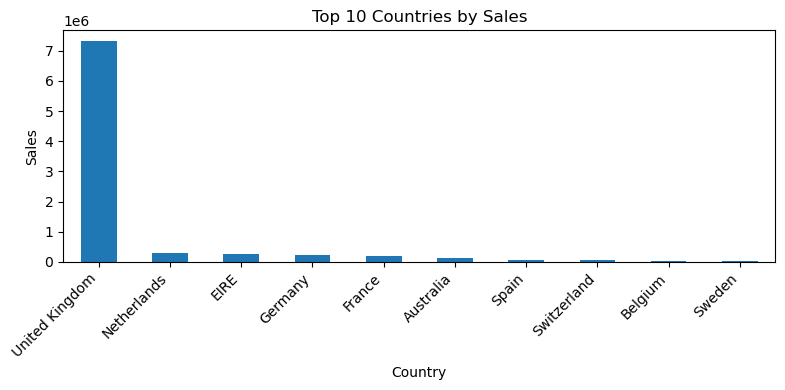

In [410]:
country_sales.plot(
    kind="bar",
    figsize=(8,4)
)

plt.title("Top 10 Countries by Sales")
plt.xlabel("Country")
plt.ylabel("Sales")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### 분석 결과 (Key Findings)

- United Kingdom이 전체 매출에서 압도적인 비중을 차지하였다.
- United Kingdom의 매출 규모가 매우 커 다른 국가 간 차이는 그래프에서 상대적으로 작게 보인다.
- United Kingdom 다음으로 Netherlands, EIRE, Germany, France 순으로 높은 매출을 기록하였다.
- 국가별 매출 편차가 커 특정 국가에 대한 매출 의존도가 높은 것으로 확인되었다.

### 국가별 매출 비교 (Excluding UK)

United Kingdom의 매출 규모가 다른 국가 대비 매우 커 상대적인 비교가 어려웠다.

따라서 United Kingdom을 제외하고 상위 국가들의 매출을 다시 비교하였다.

In [413]:
country_sales_no_uk = (
    clean_df
    .groupby("Country")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .drop("United Kingdom")
    .head(10)
)

country_sales_no_uk

Country
Netherlands    285446.34
EIRE           265545.90
Germany        228867.14
France         209024.05
Australia      138521.31
Spain           61577.11
Switzerland     56443.95
Belgium         41196.34
Sweden          38378.33
Japan           37416.37
Name: Sales, dtype: float64

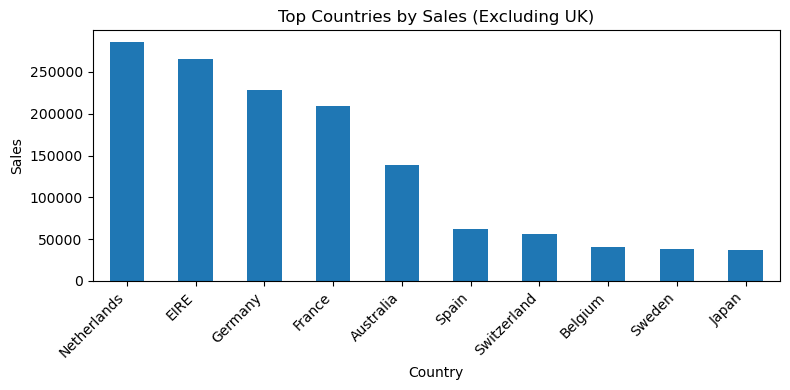

In [414]:
country_sales_no_uk.plot(
    kind="bar",
    figsize=(8,4)
)

plt.title("Top Countries by Sales (Excluding UK)")
plt.xlabel("Country")
plt.ylabel("Sales")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### 분석 결과 (Key Findings)

- United Kingdom을 제외하면 Netherlands가 가장 높은 매출을 기록하였다.
- EIRE, Germany, France가 그 뒤를 이었다.
- 상위 매출 국가 대부분이 유럽 국가로 나타났다.
- 국가별 매출 편차가 크게 나타났으며, 국가별 고객 수와의 관계를 추가로 분석할 필요가 있다.

## 6. 국가별 고객 수 분석 (Customer Distribution by Country)

국가별 고유 고객 수(CustomerID)를 집계하여 고객 분포를 확인하였다.

앞선 국가별 매출 분석에서 Netherlands와 EIRE가 높은 매출을 기록하였기 때문에,
매출 규모가 고객 수와 어떤 관계를 가지는지 추가로 분석하였다.

In [417]:
country_customers = (
    clean_df
    .groupby("Country")["CustomerID"]
    .nunique()
    .sort_values(ascending=False)
    .head(15)
)

country_customers

Country
United Kingdom     3921
Germany              94
France               87
Spain                30
Belgium              25
Switzerland          21
Portugal             19
Italy                14
Finland              12
Austria              11
Norway               10
Netherlands           9
Australia             9
Denmark               9
Channel Islands       9
Name: CustomerID, dtype: int64

### 국가별 고객 수 비교 (Excluding UK)

United Kingdom의 고객 수가 다른 국가 대비 매우 많아 상대적인 비교가 어려웠다.

따라서 United Kingdom을 제외하고 국가별 고객 수를 다시 비교하였다.

In [419]:
country_customers_no_uk = (
    clean_df
    .groupby("Country")["CustomerID"]
    .nunique()
    .sort_values(ascending=False)
    .drop("United Kingdom")
    .head(25)
)

country_customers_no_uk

Country
Germany            94
France             87
Spain              30
Belgium            25
Switzerland        21
Portugal           19
Italy              14
Finland            12
Austria            11
Norway             10
Netherlands         9
Australia           9
Denmark             9
Channel Islands     9
Cyprus              8
Sweden              8
Japan               8
Poland              6
USA                 4
Canada              4
Unspecified         4
Greece              4
EIRE                3
Israel              3
Malta               2
Name: CustomerID, dtype: int64

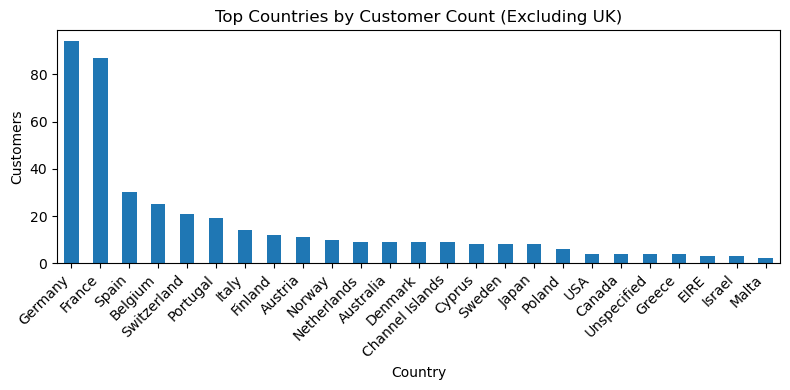

In [420]:
country_customers_no_uk.plot(
    kind="bar",
    figsize=(8,4)
)

plt.title("Top Countries by Customer Count (Excluding UK)")
plt.xlabel("Country")
plt.ylabel("Customers")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### 분석 결과 (Key Findings)

- Germany와 France가 가장 많은 고객 수를 보유하였다.
- Spain, Belgium, Switzerland 등이 그 뒤를 이었다.
- Netherlands와 EIRE는 고객 수가 매우 적은 편으로 나타났다.
- 그러나 앞선 매출 분석에서는 Netherlands와 EIRE 모두 높은 매출을 기록하였다.
- 이는 고객 수보다 고객당 평균 구매 금액이 매출에 더 큰 영향을 줄 수 있음을 시사한다.

## 7. 국가별 고객당 매출 분석 (Revenue per Customer by Country)

국가별 총 매출을 고객 수로 나누어 고객 1인당 평균 매출(Sales Per Customer)을 계산하였다.

이를 통해 고객 수가 적음에도 높은 매출을 기록한 국가가 있는지 확인하였다.

특히 고객 수가 적었던 Netherlands와 EIRE가 높은 매출을 기록한 원인을 분석하고자 하였다.

In [423]:
country_summary = (
    clean_df
    .groupby("Country")
    .agg(
        Customers=("CustomerID", "nunique"),
        Sales=("Sales", "sum")
    )
)

country_summary["SalesPerCustomer"] = (
    country_summary["Sales"] / country_summary["Customers"]
)

country_summary.sort_values(
    "SalesPerCustomer",
    ascending=False
).head(10)

,Customers,Sales,SalesPerCustomer
Country,,,
EIRE,3,265545.90,88515.300000
Netherlands,9,285446.34,31716.260000
Singapore,1,21279.29,21279.290000
Australia,9,138521.31,15391.256667
Sweden,8,38378.33,4797.291250
Japan,8,37416.37,4677.046250
Iceland,1,4310.00,4310.000000
Norway,10,36165.44,3616.544000
Switzerland,21,56443.95,2687.807143


### 분석 결과 (Key Findings)

- EIRE가 고객당 평균 매출 약 88,515로 가장 높게 나타났다.
- Netherlands 역시 고객당 평균 매출 약 31,716으로 매우 높은 수준을 기록하였다.
- Germany는 가장 많은 고객 수를 보유하였지만 고객당 평균 매출은 약 2,435 수준으로 나타났다.
- 고객 수가 많다고 반드시 높은 매출이 발생하는 것은 아니며, 고객당 구매 규모 또한 중요한 요인으로 나타났다.
- 특히 EIRE와 Netherlands는 소수의 고객이 높은 매출을 발생시킨 것으로 확인되었다.
- EIRE와 Netherlands는 고객 수가 매우 적어 일부 고객의 대량 구매가 결과에 영향을 미쳤을 가능성이 있으므로 해석에 주의가 필요하다.

## 8. 상품별 판매량 분석 (Product Sales Analysis)

상품별 판매 수량을 집계하여
가장 많이 판매된 상품을 확인하였다.

In [426]:
top_quantity = (
    clean_df
    .groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_quantity

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54415
JUMBO BAG RED RETROSPOT               46181
WHITE HANGING HEART T-LIGHT HOLDER    36725
ASSORTED COLOUR BIRD ORNAMENT         35362
PACK OF 72 RETROSPOT CAKE CASES       33693
POPCORN HOLDER                        30931
RABBIT NIGHT LIGHT                    27202
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

### 상품별 판매량 시각화 (Product Quantity Visualization)

판매량 상위 10개 상품을 시각화하였다.

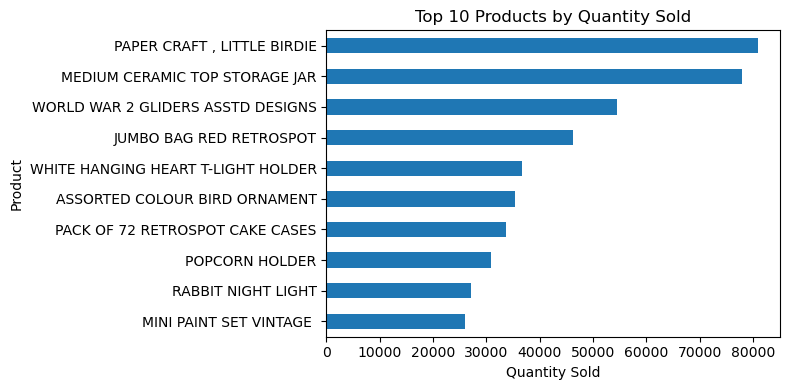

In [428]:
top_quantity.sort_values().plot(
    kind="barh",
    figsize=(8,4)
)

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

### 분석 결과 (Key Findings)

- PAPER CRAFT, LITTLE BIRDIE가 가장 높은 판매량을 기록하였다.
- MEDIUM CERAMIC TOP STORAGE JAR 역시 높은 판매량을 기록하며 상위권에 위치하였다.
- 상위 판매 상품은 주로 소형 생활용품 및 장식용 상품으로 나타났다.

## 9. 상품별 매출 분석 (Product Revenue Analysis)

상품별 총 매출을 집계하여 가장 높은 매출을 기록한 상품을 확인하였다.

이를 통해 판매량 기준 분석과 비교하여 실제 매출에 크게 기여한 상품을 파악하였다.

In [431]:
top_products = (
    clean_df
    .groupby("Description")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142592.95
WHITE HANGING HEART T-LIGHT HOLDER    100448.15
JUMBO BAG RED RETROSPOT                85220.78
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68844.33
ASSORTED COLOUR BIRD ORNAMENT          56580.34
Manual                                 53779.93
RABBIT NIGHT LIGHT                     51346.20
Name: Sales, dtype: float64

### 상품별 매출 시각화 (Product Revenue Visualization)

상위 10개 상품의 총 매출을 시각화하여 실제 매출에 가장 크게 기여한 상품을 확인하였다.

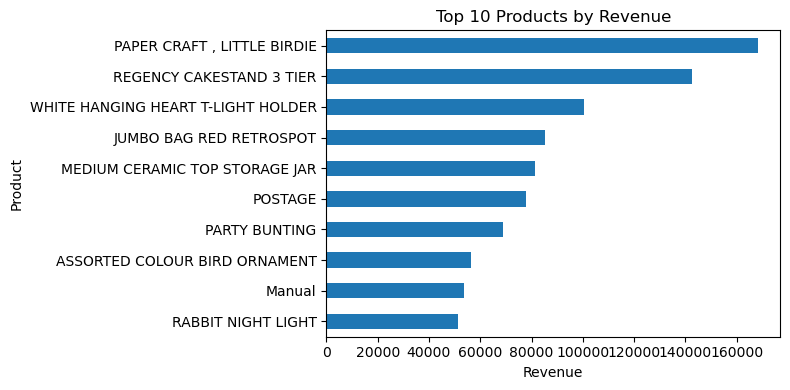

In [433]:
top_products.sort_values().plot(
    kind="barh",
    figsize=(8,4)
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

### 분석 결과 (Key Findings)

- PAPER CRAFT , LITTLE BIRDIE가 가장 높은 매출을 기록하였다.
- REGENCY CAKESTAND 3 TIER는 판매량 상위권에 없었지만 높은 매출을 기록하였다.
- 판매량 기준 상위 상품과 매출 기준 상위 상품이 일부 다르게 나타났다.
- 이는 판매량뿐 아니라 상품 가격 역시 매출에 큰 영향을 미친다는 점을 보여준다.

## 10. 고객별 매출 분석 (Customer Sales Analysis)

고객별 총 매출을 집계하여 매출 기여도가 높은 고객을 확인하였다.

이를 통해 일부 고객에게 매출이 집중되어 있는지 분석하였다.

In [436]:
top_customers = (
    clean_df
    .groupby("CustomerID")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers

CustomerID
14646    280206.02
18102    259657.30
17450    194550.79
16446    168472.50
14911    143825.06
12415    124914.53
14156    117379.63
17511     91062.38
16029     81024.84
12346     77183.60
Name: Sales, dtype: float64

### 고객별 매출 시각화 (Customer Revenue Visualization)

매출 상위 10명의 고객을 시각화하여 고객별 매출 규모를 비교하였다.

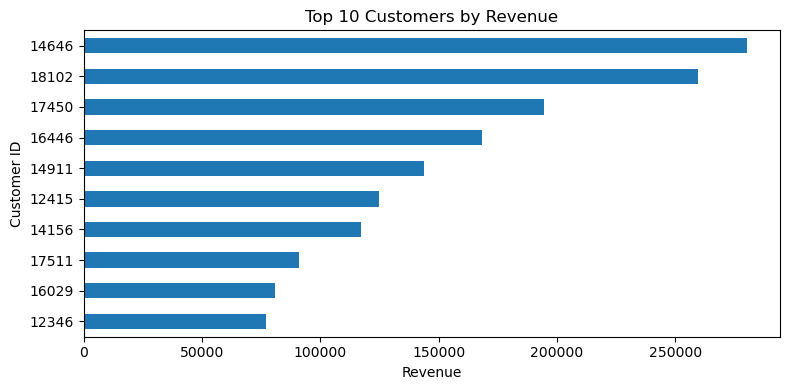

In [438]:
top_customers.sort_values().plot(
    kind="barh",
    figsize=(8,4)
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Customer ID")

plt.tight_layout()
plt.show()

### 분석 결과 (Key Findings)

- 상위 고객들의 매출 규모가 일반 고객 대비 매우 높게 나타났다.
- 일부 고객이 전체 매출에 큰 영향을 미치는 것으로 확인되었다.
- 고객별 매출 편차가 크게 나타나 매출 집중 현상이 존재함을 확인하였다, 이러한 결과는 매출 기여도가 높은 고객군의 중요성을 보여준다.

## 프로젝트 결론 (Conclusion)

이번 프로젝트에서는 Online Retail 데이터를 활용하여 매출, 고객, 상품 관점의 탐색적 데이터 분석(EDA)을 수행하였다.

- 월별 매출은 전반적으로 증가하는 추세를 보였다.
- United Kingdom이 전체 매출과 고객 수의 대부분을 차지하였다.
- Netherlands와 EIRE는 고객 수가 적음에도 높은 매출을 기록하였다.
- 고객 수보다 고객당 구매 규모가 매출에 더 큰 영향을 줄 수 있음을 확인하였다.
- 판매량이 높은 상품과 매출이 높은 상품은 일부 차이를 보였다.
- 고객별 매출 편차가 크게 나타나 매출 집중 현상이 존재함을 확인하였다.

향후에는 고객별 구매 이력 데이터를 활용하여 재구매 패턴과 고객 특성을 분석하고, 고객 그룹별 구매 행동의 차이를 비교함으로써 보다 다양한 관점에서 고객을 이해해볼 수 있을 것으로 생각된다.